In [1]:
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

/home/ec2-user/miniforge3/envs/spatial/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
adata = sc.read_h5ad(os.path.expanduser(
    "../data/processed/06_adata_final.h5ad"))

In [4]:
table_dir = os.path.expanduser("../results/tables")
figure_dir = os.path.expanduser("../results/figures/final") 

In [6]:
# palette by layers
layer_colors = {
    "Layer1": "#F0027F",
    "Layer2": "#377EB8",
    "Layer3": "#4DAF4A",
    "Layer4": "#984EA3",
    "Layer5": "#FFD700",
    "Layer6": "#FF7F00",
    "WM":     "#1A1A1A"
}
layer_order = ["Layer1", "Layer2", "Layer3", "Layer4", "Layer5", "Layer6", "WM"]
adata.obs["ground_truth"] = adata.obs["ground_truth"].astype("category")
adata.obs["ground_truth"] = adata.obs["ground_truth"].cat.set_categories(layer_order)
adata.uns["ground_truth_colors"] = [layer_colors[l] for l in layer_order]

/tmp/ipykernel_20430/201674374.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color="ground_truth", ax=ax, show=False,


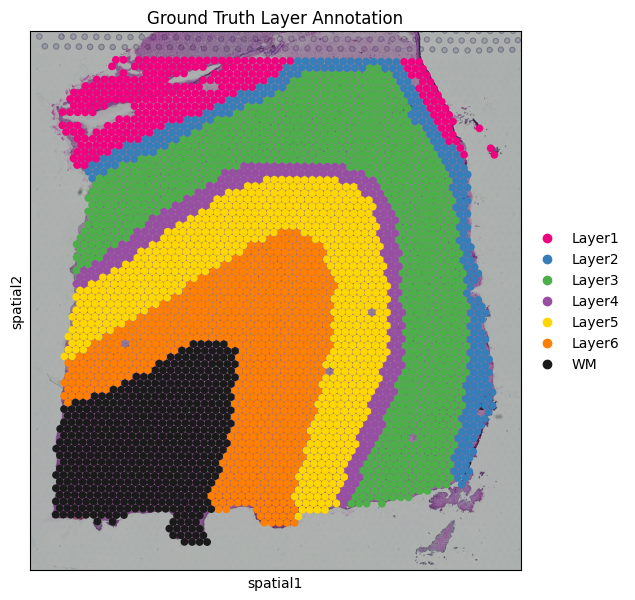

In [17]:
# H&E + Ground Truth
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
sc.pl.spatial(adata, color="ground_truth", ax=ax, show=False,
              title="Ground Truth Layer Annotation", spot_size=140)
plt.savefig(os.path.join(figure_dir, "01_ground_truth.png"), dpi=200, bbox_inches='tight')
plt.show()

/tmp/ipykernel_20430/773541358.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=metric, ax=ax, show=False,
/tmp/ipykernel_20430/773541358.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=metric, ax=ax, show=False,
/tmp/ipykernel_20430/773541358.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=metric, ax=ax, show=False,


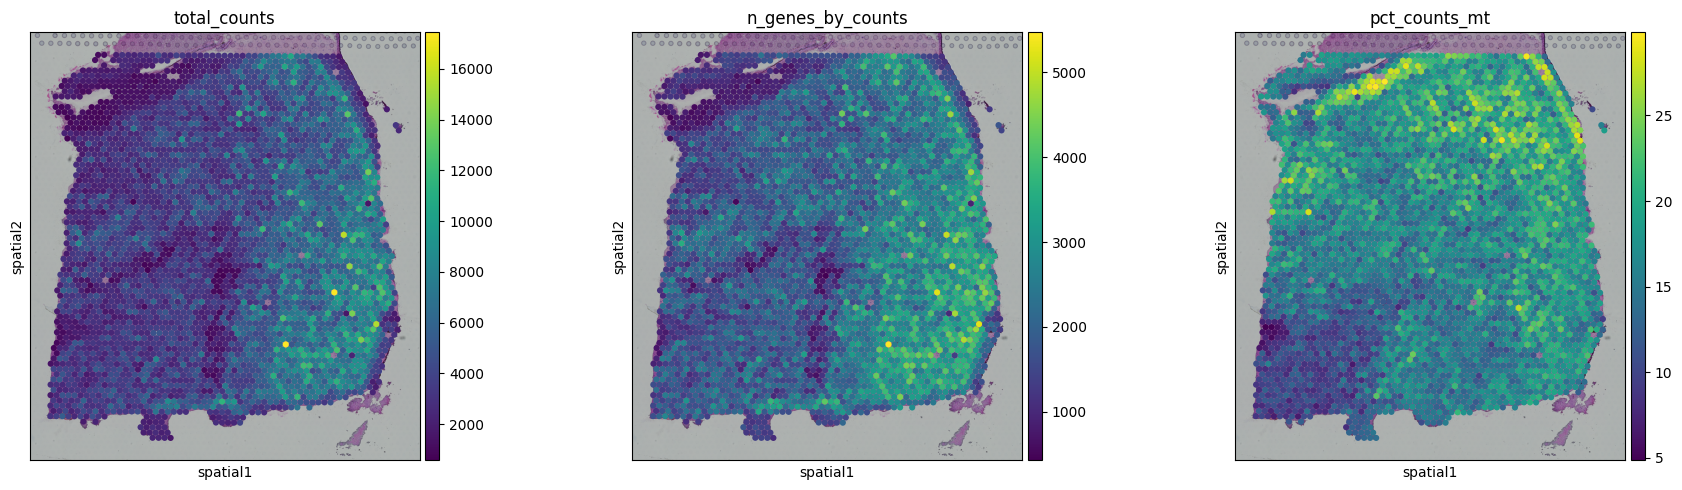

In [18]:
# QC spatial
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric in zip(axes, ['total_counts', 'n_genes_by_counts', 'pct_counts_mt']):
    sc.pl.spatial(adata, color=metric, ax=ax, show=False,
                  title=metric, spot_size=140, cmap='viridis')
plt.tight_layout()
plt.savefig(os.path.join(figure_dir, "02_B_qc.png"), dpi=200, bbox_inches='tight')
plt.show()

/tmp/ipykernel_20430/2721614520.py:8: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=gene, ax=ax, show=False,
/tmp/ipykernel_20430/2721614520.py:8: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=gene, ax=ax, show=False,
/tmp/ipykernel_20430/2721614520.py:8: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=gene, ax=ax, show=False,
/tmp/ipykernel_20430/2721614520.py:8: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=gene, ax=ax, show=False,
/tmp/ipykernel_20430/2721614520.py:8: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=gene, ax=ax, show=False,
/tmp/ipykernel_20430/2721614520.py:8: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=gene, ax=ax, show=False,
/tmp/ipykernel_20430/2721614520.py:8: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spa

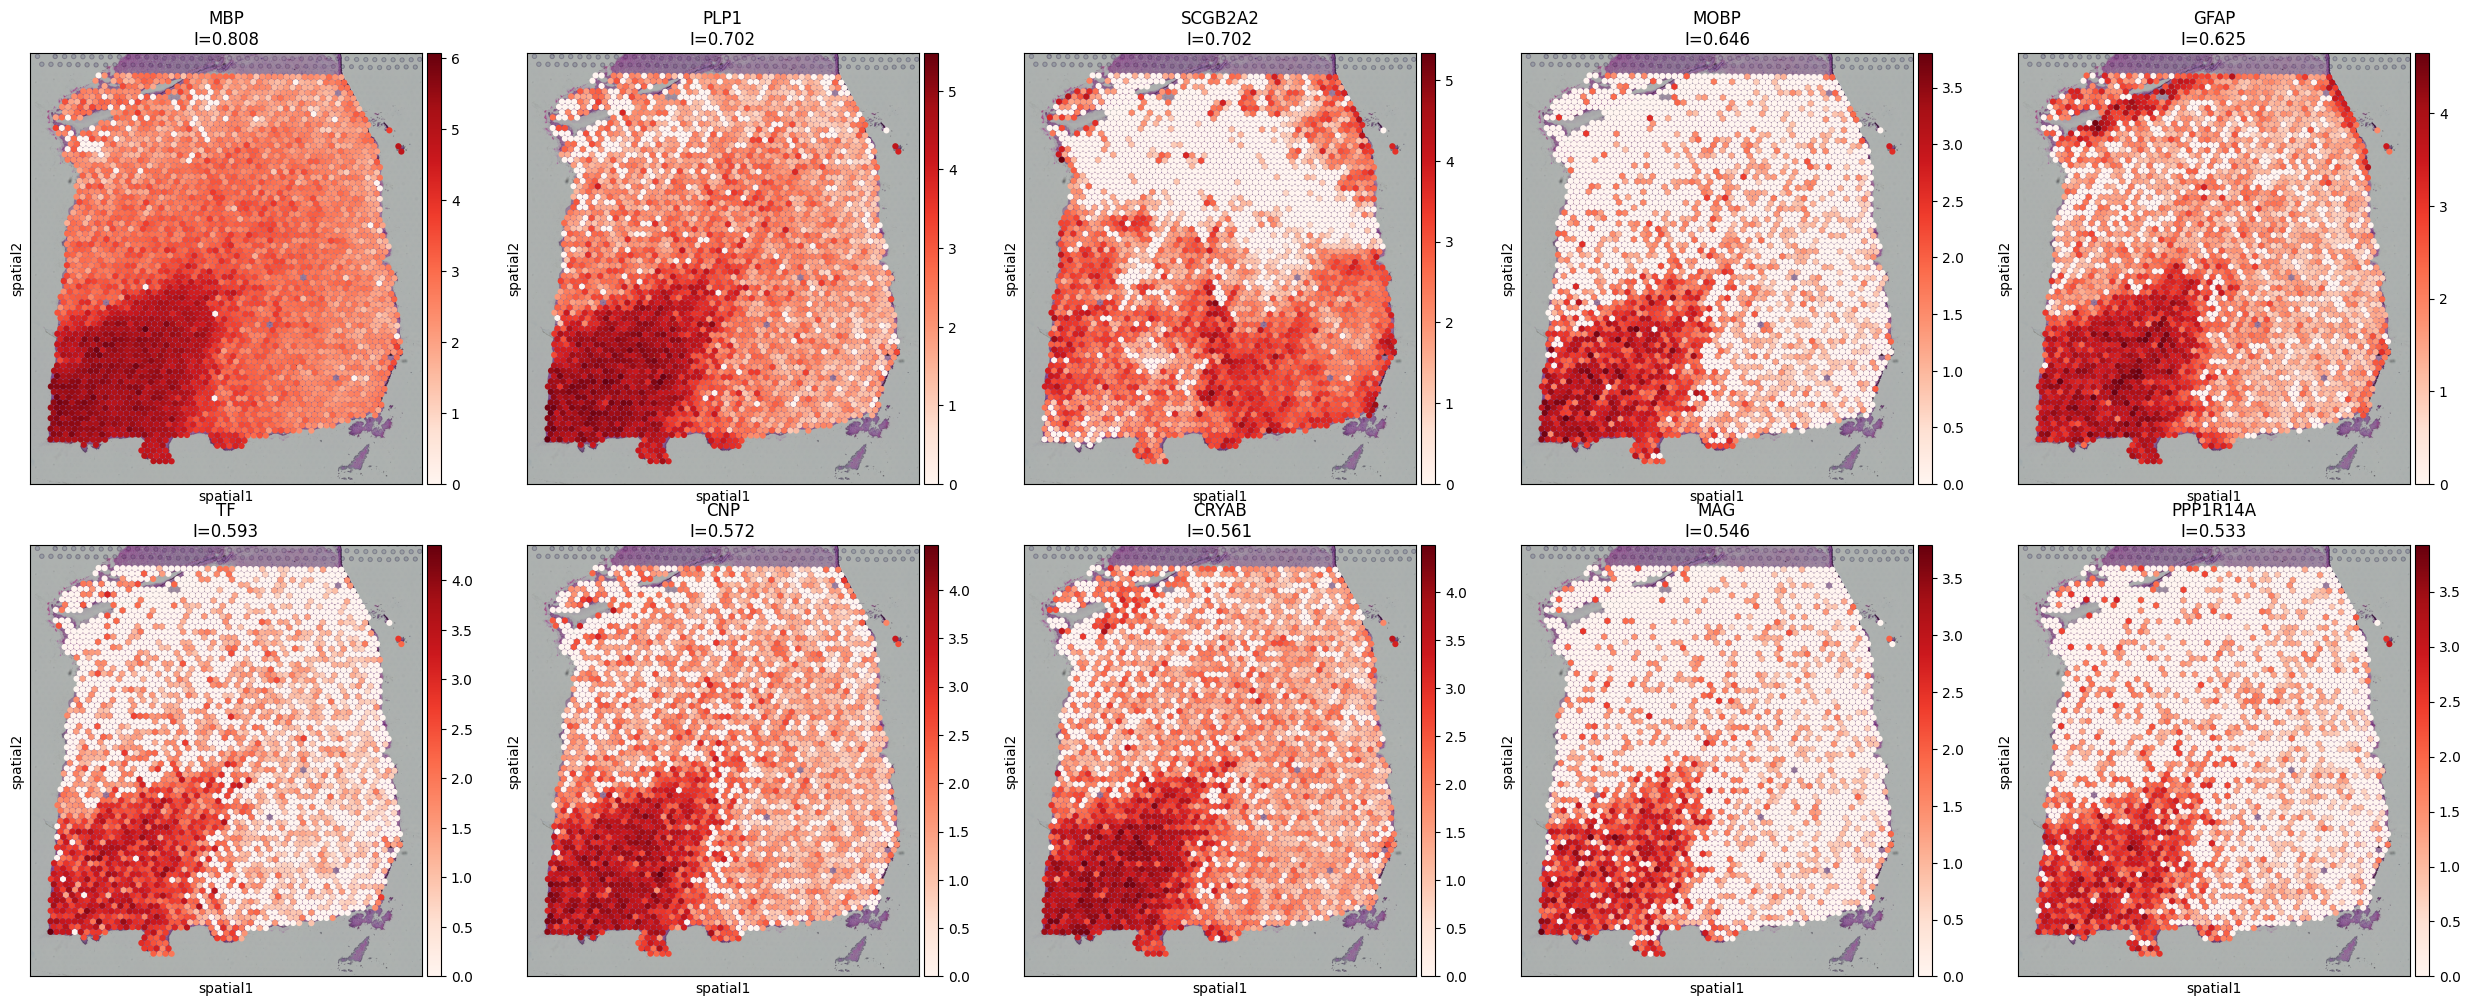

In [21]:
# SVGs - top10
moran_df = pd.read_csv(os.path.join(table_dir, "moran_I_results.csv"), index_col=0)
moran_df = moran_df.sort_values('I', ascending=False)
top10_svgs = moran_df.head(10).index.tolist()

fig, axes = plt.subplots(2, 5, figsize=(25, 10))
for ax, gene in zip(axes.flat, top10_svgs):
    sc.pl.spatial(adata, color=gene, ax=ax, show=False,
                  title=f"{gene}\nI={moran_df.loc[gene, 'I']:.3f}",
                  spot_size=140, cmap='Reds', use_raw=True)
plt.tight_layout()
plt.savefig(os.path.join(figure_dir, "03_top10_svgs.png"), dpi=200, bbox_inches='tight')
plt.show()

/tmp/ipykernel_20430/3685535759.py:12: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=gene, ax=ax, show=False,
/tmp/ipykernel_20430/3685535759.py:12: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=gene, ax=ax, show=False,
/tmp/ipykernel_20430/3685535759.py:12: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=gene, ax=ax, show=False,
/tmp/ipykernel_20430/3685535759.py:12: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=gene, ax=ax, show=False,
/tmp/ipykernel_20430/3685535759.py:12: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=gene, ax=ax, show=False,


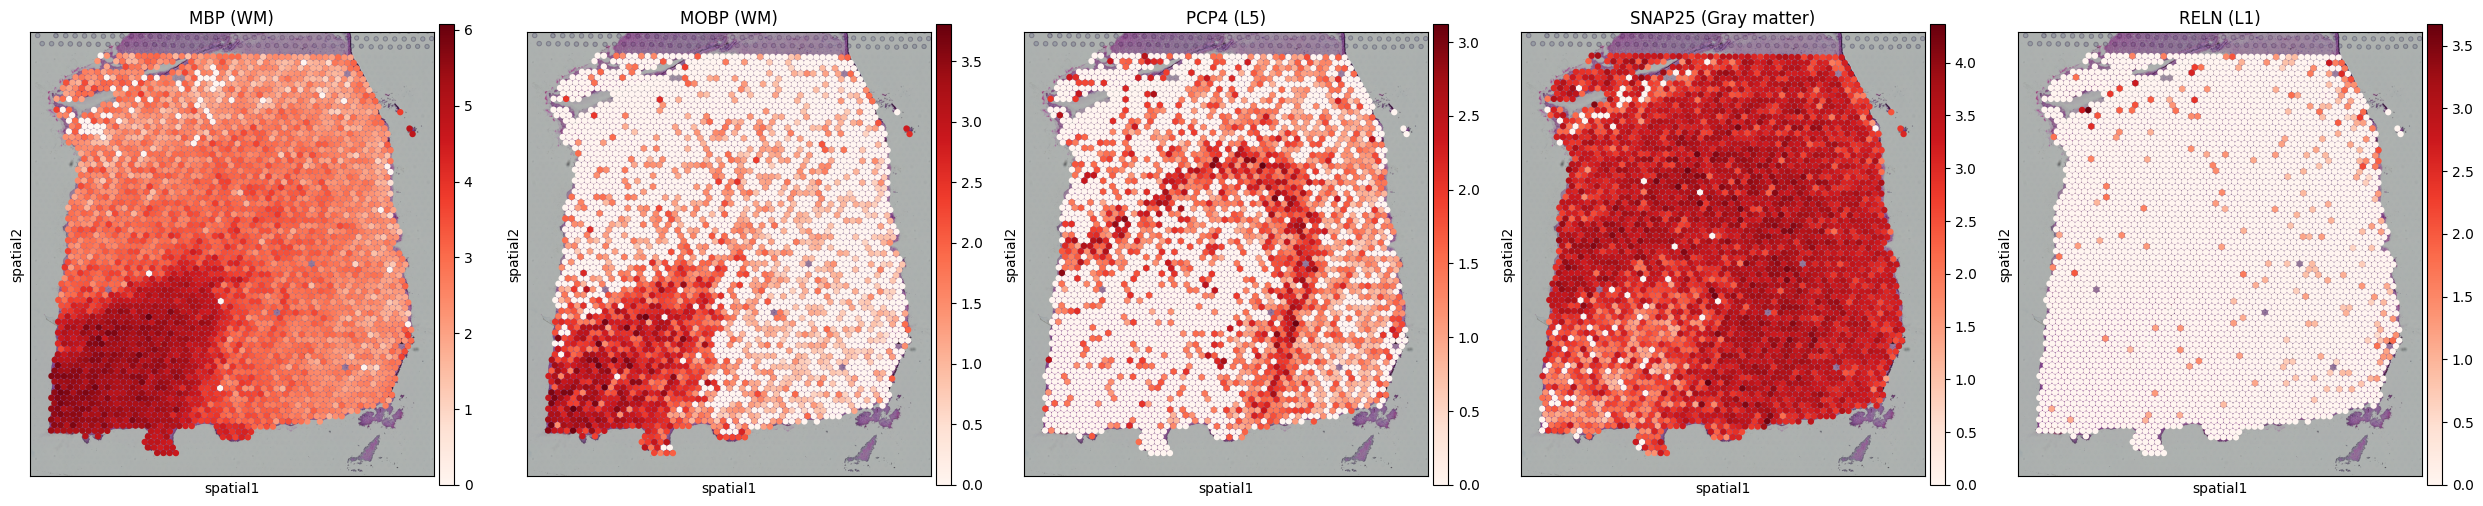

In [22]:
# known markers
known_markers = {
    'MBP': 'WM',
    'MOBP': 'WM',
    'PCP4': 'L5',
    'SNAP25': 'Gray matter',
    'RELN': 'L1'
}

fig, axes = plt.subplots(1, 5, figsize=(25, 5))
for ax, (gene, layer) in zip(axes, known_markers.items()):
    sc.pl.spatial(adata, color=gene, ax=ax, show=False,
                  title=f"{gene} ({layer})",
                  spot_size=140, cmap='Reds', use_raw=True)
plt.tight_layout()
plt.savefig(os.path.join(figure_dir, "04_known_markers.png"), dpi=200, bbox_inches='tight')
plt.show()

/tmp/ipykernel_20430/2787047249.py:10: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=col, ax=ax, show=False,
/tmp/ipykernel_20430/2787047249.py:10: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=col, ax=ax, show=False,
/tmp/ipykernel_20430/2787047249.py:10: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=col, ax=ax, show=False,
/tmp/ipykernel_20430/2787047249.py:10: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=col, ax=ax, show=False,


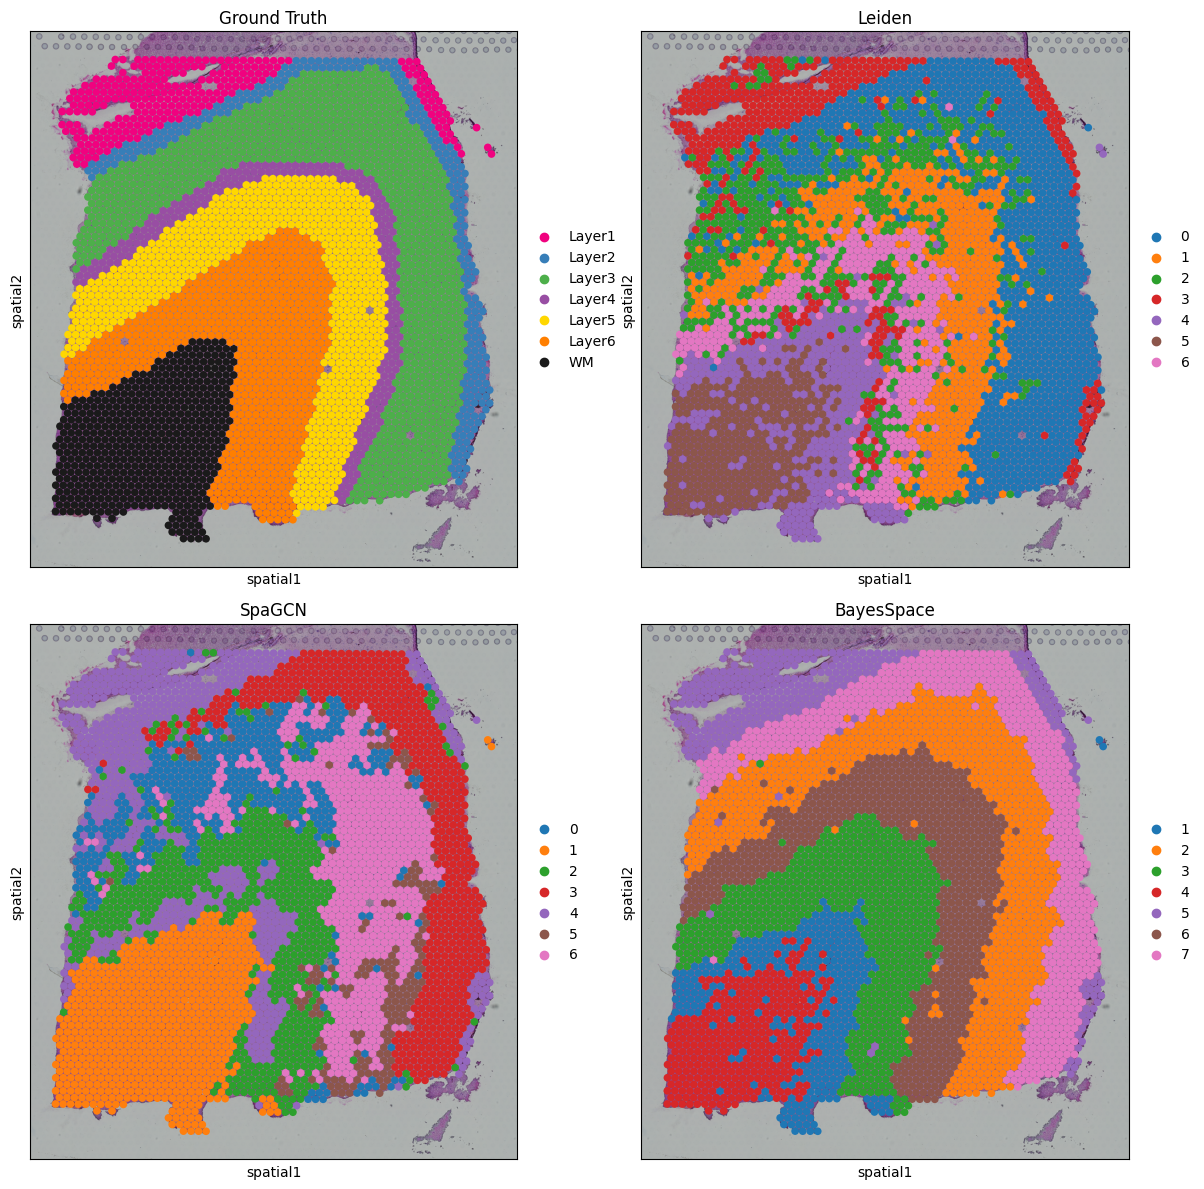

In [25]:
# clustering comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
panels = [
    ("Ground Truth", "ground_truth"),
    ("Leiden", "leiden"),
    ("SpaGCN", "spagcn_refined"),
    ("BayesSpace", "bayesspace")
]
for ax, (title, col) in zip(axes.flat, panels):
    sc.pl.spatial(adata, color=col, ax=ax, show=False,
                  title=title, spot_size=140)
plt.tight_layout()
plt.savefig(os.path.join(figure_dir, "05_clustering.png"), dpi=200, bbox_inches='tight')
plt.show()

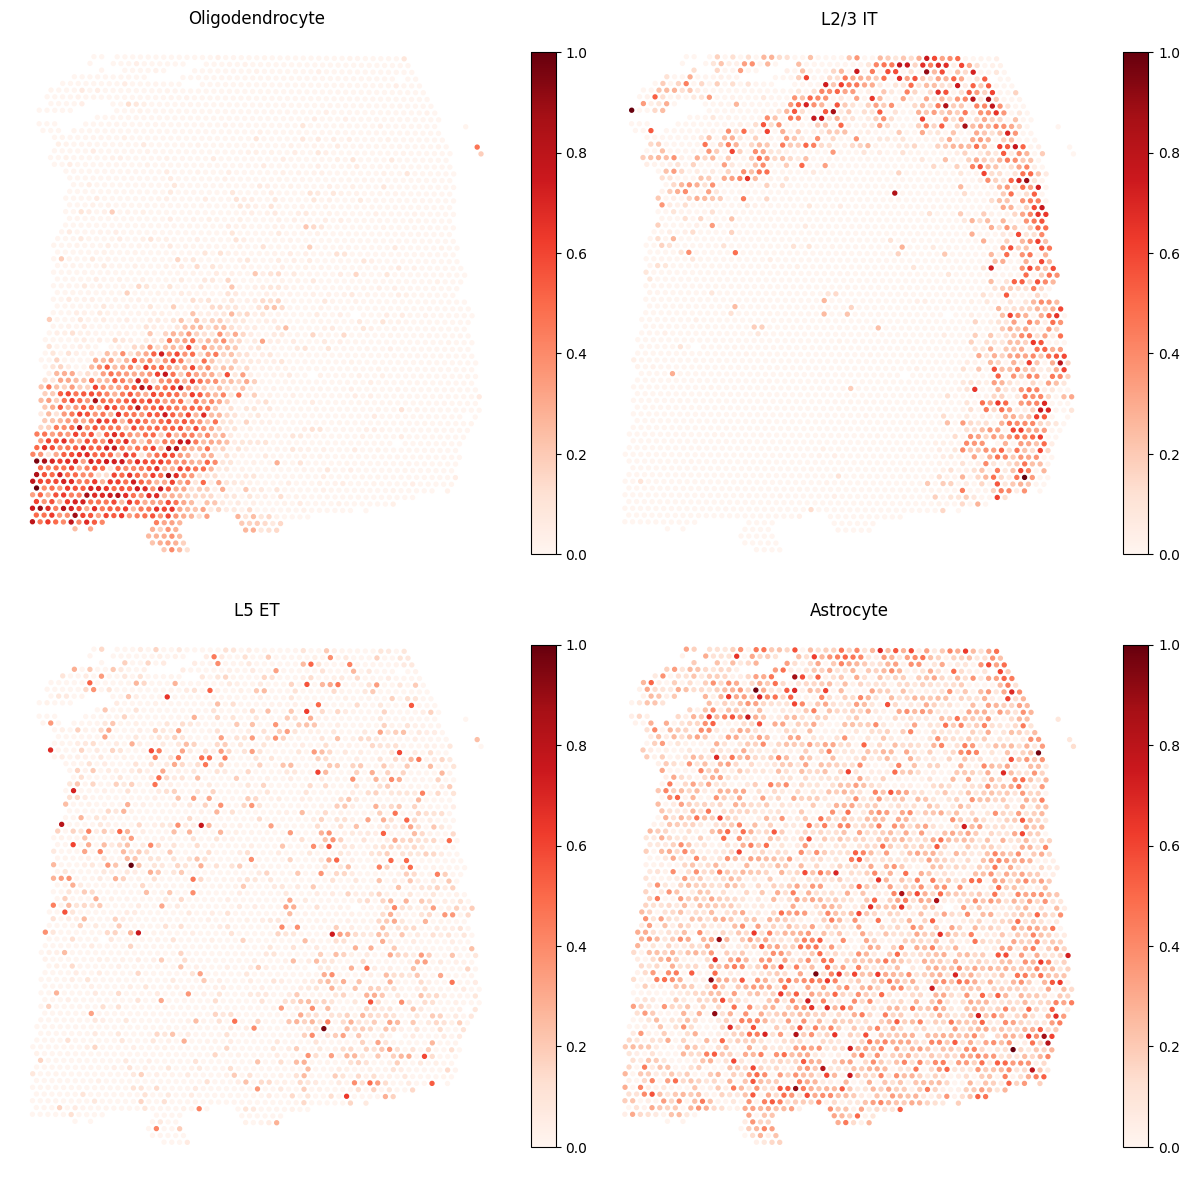

In [26]:
# tangram_deconvolution
ct_pred = adata.obsm['tangram_ct_pred']
ct_norm = ct_pred.div(ct_pred.max(axis=0), axis=1)
key_cts = ['Oligodendrocyte', 'L2/3 IT', 'L5 ET', 'Astrocyte']

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
coords = adata.obsm['spatial']
for ax, ct in zip(axes.flat, key_cts):
    sc_plot = ax.scatter(coords[:, 0], coords[:, 1],
                        c=ct_norm[ct].values, cmap='Reds', s=8, vmin=0, vmax=1)
    ax.set_title(ct)
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.axis('off')
    plt.colorbar(sc_plot, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig(os.path.join(figure_dir, "06_deconvolution.png"), dpi=200, bbox_inches='tight')
plt.show()

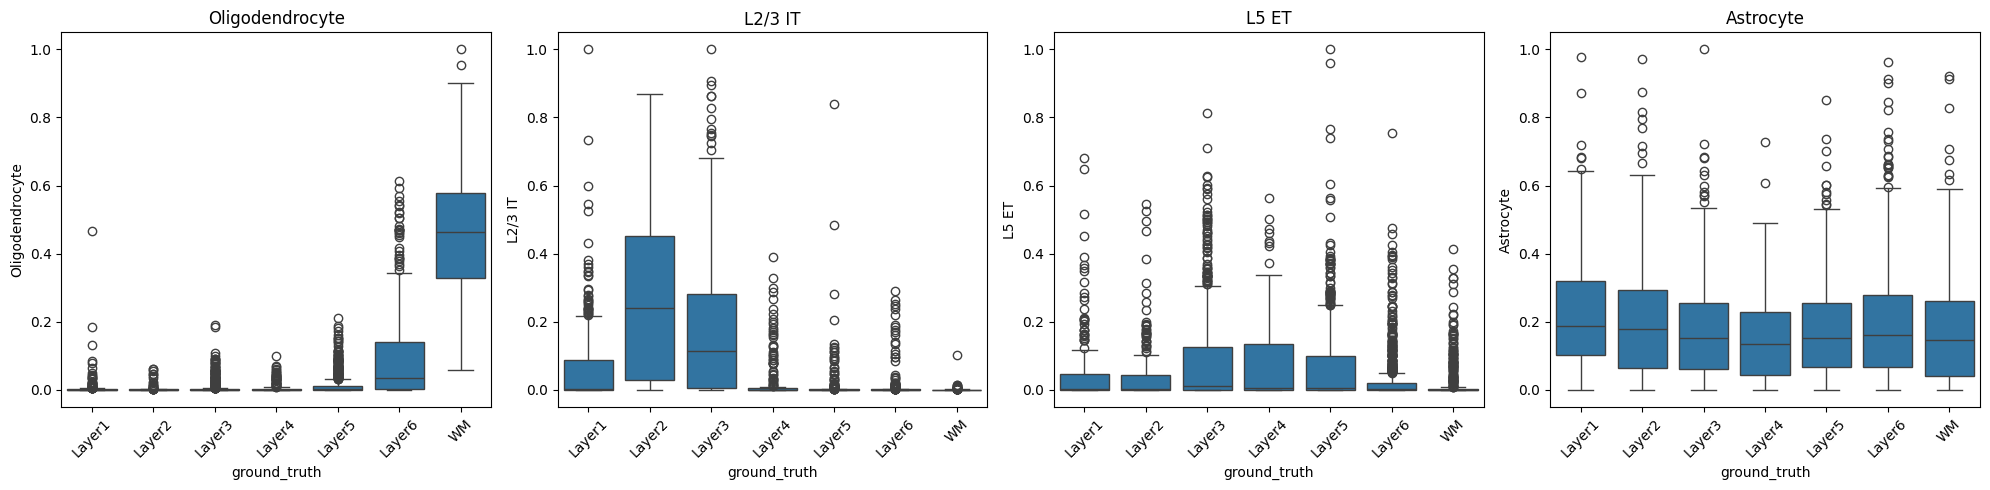

In [27]:
# deconvolution boxplot
import seaborn as sns

ct_norm = ct_pred.div(ct_pred.max(axis=0), axis=1)
ct_with_gt = ct_norm.copy()
ct_with_gt["ground_truth"] = adata.obs["ground_truth"].values

key_cts = ['Oligodendrocyte', 'L2/3 IT', 'L5 ET', 'Astrocyte']
layer_order = ["Layer1", "Layer2", "Layer3", "Layer4", "Layer5", "Layer6", "WM"]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, ct in enumerate(key_cts):
    data = ct_with_gt[ct_with_gt["ground_truth"].notna()]
    sns.boxplot(data=data, x="ground_truth", y=ct, ax=axes[i],
                order=layer_order)
    axes[i].set_title(ct)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(figure_dir, "07_tangram_ct_by_layer_boxplot.png"), dpi=200, bbox_inches='tight')
plt.show()

INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           


100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 3489.76/s]


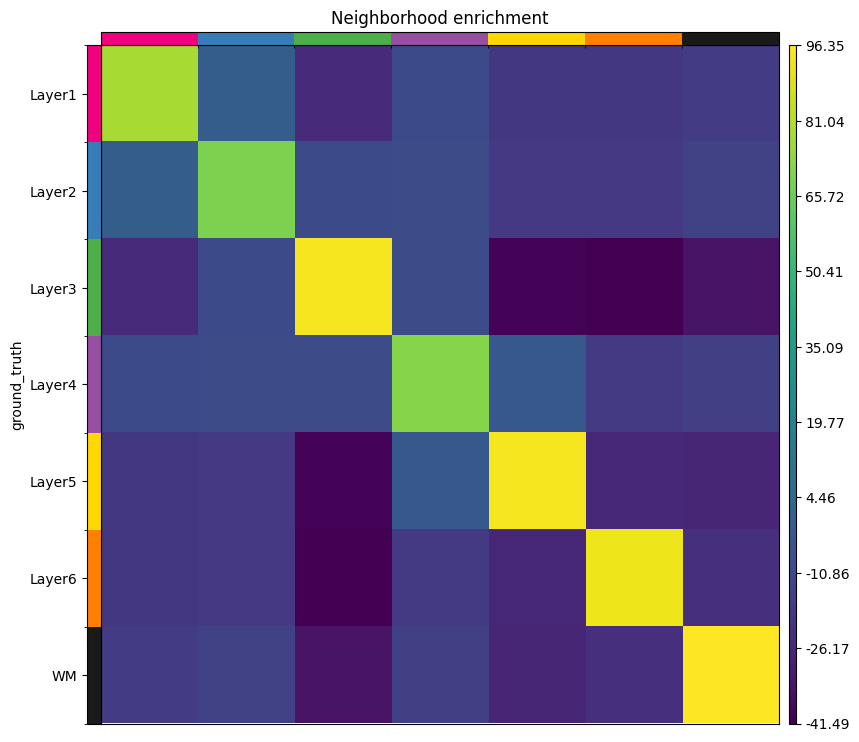

In [29]:
# Neighborhood enrichment heatmap - gt
sq.gr.spatial_neighbors(adata)
sq.gr.nhood_enrichment(adata, cluster_key="ground_truth")
sq.pl.nhood_enrichment(adata, cluster_key="ground_truth", figsize=(8, 7))
plt.savefig(os.path.join(figure_dir, "08_nhood_enrichment_gt.png"), dpi=200, bbox_inches='tight')
plt.show()

INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           


100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 3566.26/s]


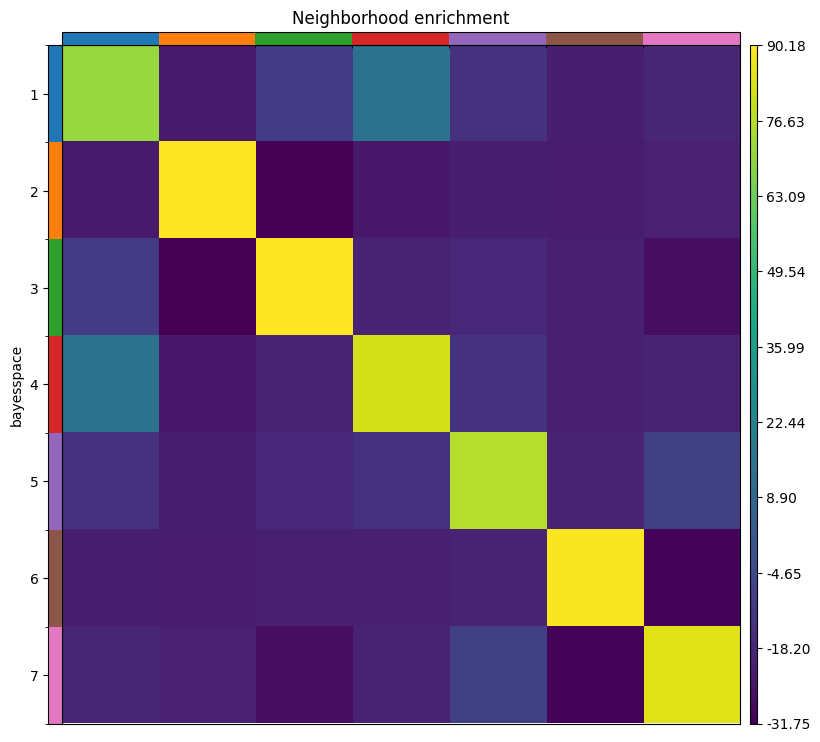

In [30]:
# Neighborhood enrichment heatmap - BayesSpace
sq.gr.spatial_neighbors(adata)
sq.gr.nhood_enrichment(adata, cluster_key="bayesspace")
sq.pl.nhood_enrichment(adata, cluster_key="bayesspace", figsize=(8, 7))
plt.savefig(os.path.join(figure_dir, "09_nhood_enrichment_bs.png"), dpi=200, bbox_inches='tight')
plt.show()

In [32]:
# Methods comparison
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

mask = adata.obs['ground_truth'].notna()
methods = {"Leiden": "leiden", "SpaGCN": "spagcn_refined", "BayesSpace": "bayesspace"}

rows = []
for name, col in methods.items():
    ari = adjusted_rand_score(adata.obs.loc[mask, 'ground_truth'], adata.obs.loc[mask, col])
    nmi = normalized_mutual_info_score(adata.obs.loc[mask, 'ground_truth'], adata.obs.loc[mask, col])
    rows.append({"Method": name, "ARI": round(ari, 4), "NMI": round(nmi, 4),
                 "Uses Spatial": name != "Leiden", "Uses Histology": name == "SpaGCN"})

comparison = pd.DataFrame(rows)
comparison.to_csv(os.path.join("../results/tables", "clustering_comparison.csv"), index=False)
print(comparison.to_markdown(index=False))

| Method     |    ARI |    NMI | Uses Spatial   | Uses Histology   |
|:-----------|-------:|-------:|:---------------|:-----------------|
| Leiden     | 0.3882 | 0.5009 | False          | False            |
| SpaGCN     | 0.3163 | 0.4593 | True           | True             |
| BayesSpace | 0.5355 | 0.6729 | True           | False            |


In [34]:
sq.gr.ripley(adata, cluster_key="ground_truth", mode="L")

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
sq.pl.ripley(adata, cluster_key="ground_truth", mode="L",
             figsize=(10, 8), ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(figure_dir, "10_ripley_L.png"),
            dpi=200, bbox_inches='tight')
plt.close()

In [33]:
adata.write("../data/processed/07_final.h5ad")

/home/ec2-user/miniforge3/envs/spatial/lib/python3.12/site-packages/anndata/_io/utils.py:272: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release
  return func(*args, **kwargs)
/home/ec2-user/miniforge3/envs/spatial/lib/python3.12/site-packages/anndata/_io/utils.py:272: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release
  return func(*args, **kwargs)
/home/ec2-user/miniforge3/envs/spatial/lib/python3.12/site-packages/anndata/_io/utils.py:272: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release
  return func(*args, **kwargs)
/home/ec2-user/miniforge3/envs/spatial/lib/python3.12/site-packages/anndata/_io/utils.py:272: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release
  return func(*args, **kwargs)
